# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split,KFold
import matplotlib.pyplot as plt
import seaborn as sns

## Завантаження та обробка даних

In [2]:
df = pd.read_csv('data/train.csv')
df

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [3]:
df.drop(["datetime","registered","casual","atemp"], axis=1, inplace=True)
df

,season,holiday,workingday,weather,temp,humidity,windspeed,count
0,1,0,0,1,9.84,81,0.0000,16
1,1,0,0,1,9.02,80,0.0000,40
2,1,0,0,1,9.02,80,0.0000,32
3,1,0,0,1,9.84,75,0.0000,13
4,1,0,0,1,9.84,75,0.0000,1
...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,50,26.0027,336
10882,4,0,1,1,14.76,57,15.0013,241
10883,4,0,1,1,13.94,61,15.0013,168
10884,4,0,1,1,13.94,61,6.0032,129


## Початковий аналіз та обробка даних 
(перевірка на пропущені значення, типи фічерів, їх початкова обробка для подальшого аналізу)

In [4]:
# Перевірка розміру датасету
df.shape

(10886, 8)

In [5]:
# Перевірка на наявність пропущених значень
df.isna().sum()

season        0
holiday       0
workingday    0
weather       0
temp          0
humidity      0
windspeed     0
count         0
dtype: int64

In [6]:
# Дивимось на кількість унікальних значень кожного фічера 
# (таким чином можемо знайти категоріальні фічери та їх кількість унікальних значень)
df.nunique()

season          4
holiday         2
workingday      2
weather         4
temp           49
humidity       89
windspeed      28
count         822
dtype: int64

In [7]:
# Дивимось на типи даних кожного фічера 
# (object часто означає категоріальний фічер у форматі string, який треба буде обробити)
df.dtypes

season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
humidity        int64
windspeed     float64
count           int64
dtype: object

## Побудова графіків для аналізу даних

#### Побудова кореляційної матриці фічерів

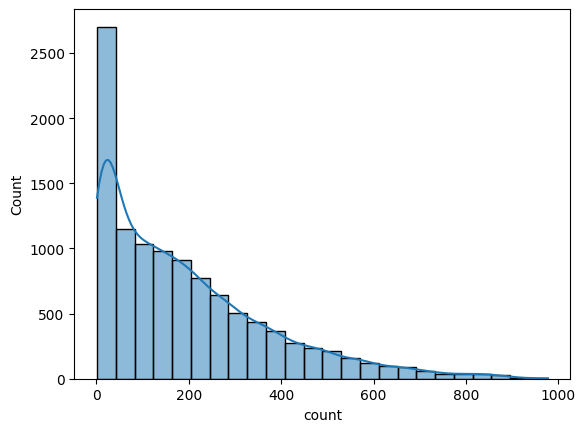

In [8]:
# plt.hist(df["Age"], bins=20)
sns.histplot(data=df, x='count', binwidth=40, kde=True)
plt.show()

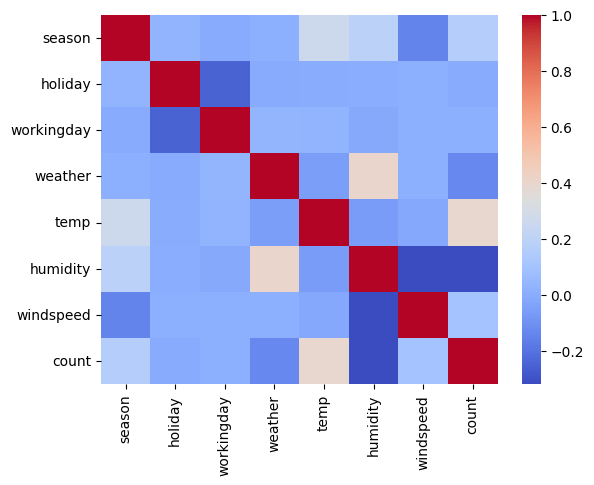

In [9]:
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Розділ даних

In [10]:
x = df.drop(columns=["count"])
y = df["count"]

###  train/val/test split

In [11]:
x_train, x_val_test, y_train, y_val_test = train_test_split(x, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_val_test, y_val_test, test_size=0.5, random_state=42)
x_train.shape, x_val.shape, x_test.shape

((6531, 7), (2177, 7), (2178, 7))

In [12]:
x_train.to_csv("data/processed_data/x_train.csv", index=False)
x_val.to_csv("data/processed_data/x_val.csv", index=False)
x_test.to_csv("data/processed_data/x_test.csv", index=False)

y_train.to_csv("data/processed_data/y_train.csv", index=False)
y_val.to_csv("data/processed_data/y_val.csv", index=False)
y_test.to_csv("data/processed_data/y_test.csv", index=False)